In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import os.path

In [3]:
%%capture
%run ./DTW.ipynb

In [4]:
def midi_measure(measure_boundaries, wp):
    """
    Get the midi measure boundaries as frames
    """

    midi_measure_frames = []
    start_midi = 0

    for i in range(measure_boundaries.shape[0]):
        end_xml = measure_boundaries[i]
        adjustment = 0

        while (np.where(wp[1] == end_xml)[0]).size < 1:
            end_xml -= 1 # adjust boundary slightly if exact frame is not listed
            adjustment += 1

        end_idx = np.where(wp[1] == end_xml)[0][0]

        end_midi = wp[0][end_idx] + adjustment
        midi_measure_frames.append((start_midi,end_midi))
        start_midi = end_midi

    return midi_measure_frames

In [5]:
def midi_times(mid_frames, midi_file, save = False, onset=False):
    """convert frames of midi to time using fs"""

    midi_data = np.load(midi_file)
    fs = midi_data['fs']
    midi_measure_times = mid_frames/fs

    file_name = midi_file[14:-8] + ".txt"

    if onset:
        file_name = 'onset' + file_name

    if save:
        np.savetxt(os.path.join('annots', file_name), midi_measure_times[:,1], delimiter = ' ')
    return midi_measure_times

In [6]:

midi_dir = 'midi_features'
xml_dir = 'xml_features'

# file = 'bach_fugue_bwv_846.mid.npz'
# xml = 'bach_fugue_bwv_846.musicxml.npz'

# file = 'schumann_arabeske_park.mid.npz'
# xml = 'schumann_arabeske.musicxml.npz'

# file = 'brahms_Shilyaev03.mid.npz'
# xml = 'brahms.musicxml.npz'

# file = 'glinka.mid.npz'
# xml = 'glinka.musicxml.npz'

# file = 'Beethoven-Chen.mid.npz'
# xml = 'Beethovem-30-1.musicxml.npz'

# file = 'Chopin-LeeKoeun.mid.npz'
# xml = 'Chopin-Ballades-1.musicxml.npz'

# file = 'debussy.mid.npz'
# xml = 'debussy.musicxml.npz'

# file = 'Haydn-6-1.mid.npz'
# xml = 'Haydn-6-1.musicxml.npz' # little strange

# file = 'liszt_concert_etude_s145_Kleisen03.mid.npz'
# xml = 'liszt_concert_etude_s145_1.musicxml.npz'

file = 'Mozart-fantasie.mid.npz'
xml = 'Mozart-Fantasie.musicxml.npz' # little strange

# file = 'Prokofiev-Toccata.mid.npz'
# xml = 'Prokofiev-Toccata.musicxml.npz'

# file = 'Ravel.mid.npz'
# xml = 'Ravel.musicxml.npz'

featfile1 = os.path.join(midi_dir, file)
featfile2 = os.path.join(xml_dir, xml)

xml_data = np.load(featfile2)
measure_boundaries = xml_data['measure_boundaries']
midi_data = np.load(featfile1)
fs = midi_data['fs']

steps = np.array([0,1,1,0,1,1]).reshape((-1,2))
weights = np.array([1,1,2])
downsample = 1
wp, C = alignDTW(featfile1, featfile2, steps, weights, downsample)

(88, 12454)
(88, 12160)


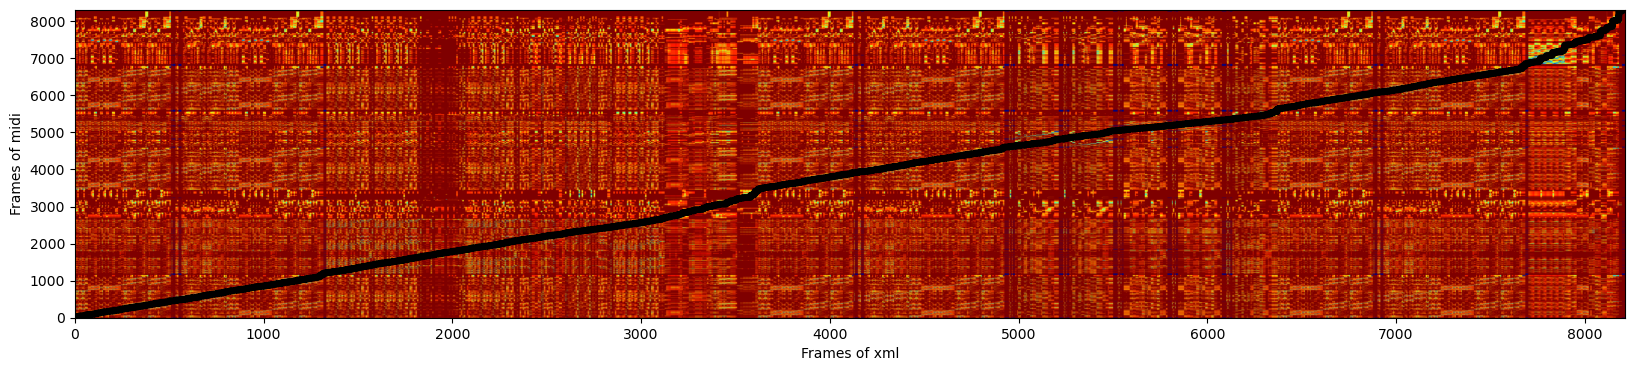

In [100]:
plt.figure(figsize=(20,4))

plt.imshow(C, cmap = 'jet', origin = 'lower', aspect='auto')
# plt.imshow(C, cmap = 'jet', origin = 'lower')
plt.plot(wp[1,:], wp[0,:], 'k', linewidth = 5)
plt.xlabel("Frames of xml")
plt.ylabel("Frames of midi")
plt.show()

In [85]:
# np.set_printoptions(threshold=10000000)
# print(wp)

In [7]:
def visualize_alignment(wp, midi_file, xml_file, start_measure, end_measure, display_measures=True):
    xml_data = np.load(xml_file)
    xml_matrix = xml_data['roll']
    measure_boundaries = xml_data['measure_boundaries']
    midi_data = np.load(midi_file)
    midi_matrix = midi_data['roll']

    combxml = np.zeros((88,wp.shape[1]*2))
    combmid = np.zeros((88,wp.shape[1]*2))

    if start_measure == 0:
        start_frame = 0
    else:
        start_frame = measure_boundaries[start_measure-1]

    if end_measure == -1:
        end_frame = measure_boundaries[-1]
    else:
        end_frame = measure_boundaries[end_measure-1]

    while (np.where(wp[1] == start_frame)[0]).size < 1:
        start_frame -= 1 # adjust boundary slightly if exact frame is not listed
    while (np.where(wp[1] == end_frame)[0]).size < 1:
        end_frame -= 1 # adjust boundary slightly if exact frame is not listed

    start_idx = np.where(wp[1] == start_frame)[0][0]
    end_idx = np.where(wp[1] == end_frame)[0][0]



    for col in range(combxml.shape[1]):
        if col % 2 == 0: # if even do xml
            ind = wp[1,col//2]
            combxml[:,col] = xml_matrix[:,ind]
        else:
            ind = wp[0,col//2]
            combmid[:,col] = midi_matrix[:,ind]

    idxs = []

    if display_measures and ((end_measure - start_measure) > 2):
        for frame in measure_boundaries[start_measure:end_measure-1]:

            while (np.where(wp[1] == frame)[0]).size < 1:
                frame -= 1 # adjust boundary slightly if exact frame is not listed
                adjustment += 1

            idx = np.where(wp[1] == frame)[0][0]
            idxs.append(idx)

        idxs = [i * 2 for i in idxs]
        
        if not start_measure == 0:
            offset = idxs[0] + (idxs[0] - idxs[1])
            idxs = [x - offset for x in idxs]
    
    plt.figure(figsize=(6,4))
    # plt.title('MIDI and XML Frames in Aligned Path')
    plt.imshow(combmid[:,start_idx*2:end_idx*2], cmap = ListedColormap(['white', 'deeppink']), alpha = 1, origin = 'lower', aspect='auto', interpolation='none')
    plt.imshow(combxml[:,start_idx*2:end_idx*2], cmap = ListedColormap(['white', 'darkgreen']), alpha = 0.6, origin = 'lower', aspect='auto', interpolation='none')
    plt.vlines(x=idxs, ymin=0, ymax=88, colors='purple', ls='--', lw=2, label='vline_multiple - full height')
    plt.ylabel('Piano Key')
    plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    plt.ylim(20,60)
    pink_patch = mpatches.Patch(color='deeppink', label='MIDI')
    green_patch = mpatches.Patch(color='darkgreen', label='XML')
    plt.legend(handles=[pink_patch, green_patch], loc='lower right')
    plt.show()
    
    plt.figure(figsize=(11,6))
    plt.title('XML')
    # plt.imshow(combmid[:,start_idx*2:end_idx*2], cmap = ListedColormap(['white', 'deeppink']), alpha = 1, origin = 'lower', aspect='auto')
    plt.imshow(combxml[:,start_idx*2:end_idx*2], cmap = ListedColormap(['white', 'darkgreen']), alpha = 1, origin = 'lower', aspect='auto')
    plt.vlines(x=idxs, ymin=0, ymax=88, colors='purple', ls='--', lw=2, label='vline_multiple - full height')
    plt.ylabel('Piano Key')
    plt.show()

    plt.figure(figsize=(11,6))
    plt.title('MIDI')
    plt.imshow(combmid[:,start_idx*2:end_idx*2], cmap = ListedColormap(['white', 'deeppink']), alpha = 1, origin = 'lower', aspect='auto')
    # plt.imshow(combxml[:,start_idx*2:end_idx*2], cmap = ListedColormap(['white', 'darkgreen']), alpha = 0.5, origin = 'lower', aspect='auto')
    plt.vlines(x=idxs, ymin=0, ymax=88, colors='purple', ls='--', lw=2, label='vline_multiple - full height')
    plt.ylabel('Piano Key')
    plt.show()

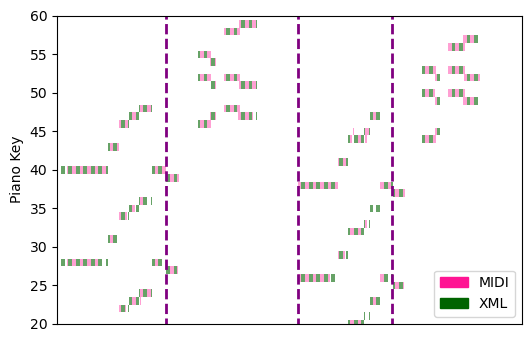

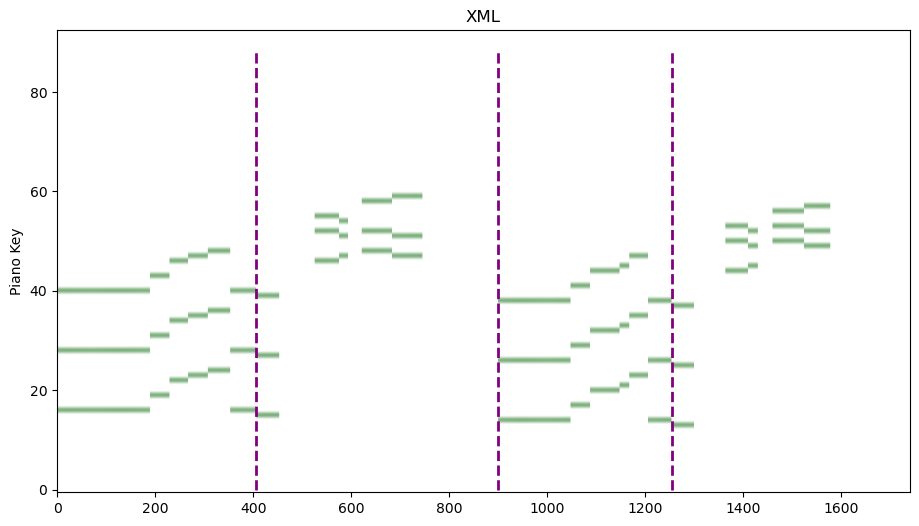

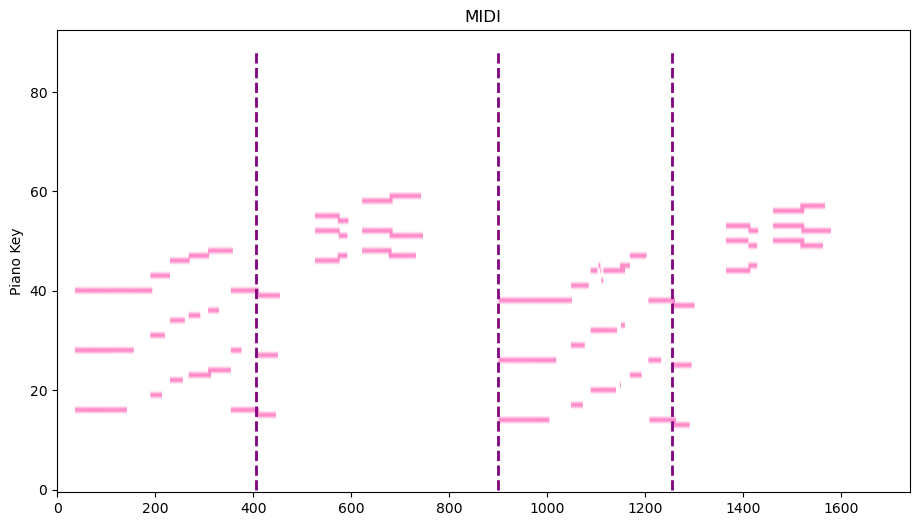

In [8]:
visualize_alignment(wp, featfile1, featfile2, 0, 4, display_measures=True)

In [338]:
midi_measure_frames = midi_measure(measure_boundaries, wp)
times = midi_times(midi_measure_frames, featfile1, save = True, onset = True)